# 01 — Nanoparticle Dataset Exploration

## Objective

This notebook performs the initial exploration and quality assessment of the nanoparticle dataset before preprocessing and machine-learning model development.

## Main tasks

1. Load the raw nanoparticle dataset
2. Inspect dataset structure
3. Examine variable types
4. Identify missing values
5. Check duplicated samples
6. Examine basic descriptive statistics
7. Explore input and output variable distributions

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Packages loaded successfully.")

Packages loaded successfully.


In [93]:
from pathlib import Path

DATA_PATH = Path("../data/raw/Dataset.csv")

print("Dataset path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

Dataset path: ..\data\raw\Dataset.csv
File exists: True


In [94]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head(10)

Dataset loaded successfully.
Shape: (6575, 15)


,ID,Glucan Type,Modification,Carrier 1,Carrier 2 (NH2),Carrier 1 Mass Ratio,Carrier 2 Mass Ratio,Glucan MW,Glucan / Carrier 2 Mass Ratio,Particle Size (nm),PDI,Zeta Potential (mV),Cell Uptake (%),Cell Uptake (MFI),M1 Marker (MFI)
0,YG-SA-D1-N1-R90-10-MH-G01,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,High,0.1,NaN,NaN,NaN,NaN,NaN,NaN
1,YG-SA-D1-N1-R90-10-MH-G08,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,High,0.8,NaN,NaN,NaN,NaN,NaN,NaN
2,YG-SA-D1-N1-R90-10-MH-G20,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,High,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,YG-SA-D1-N1-R90-10-MM-G01,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,Medium,0.1,NaN,NaN,NaN,NaN,NaN,NaN
4,YG-SA-D1-N1-R90-10-MM-G08,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,Medium,0.8,NaN,NaN,NaN,NaN,NaN,NaN
5,YG-SA-D1-N1-R90-10-MM-G20,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,Medium,2.0,NaN,NaN,NaN,NaN,NaN,NaN
6,YG-SA-D1-N1-R90-10-ML-G01,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,Low,0.1,NaN,NaN,NaN,NaN,NaN,NaN
7,YG-SA-D1-N1-R90-10-ML-G08,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,Low,0.8,NaN,NaN,NaN,NaN,NaN,NaN
8,YG-SA-D1-N1-R90-10-ML-G20,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,Low,2.0,NaN,NaN,NaN,NaN,NaN,NaN
9,YG-SA-D1-N1-R90-10-MU-G01,Yeast Glucan,Succinic anhydride modification,D1,N1,0.9,0.1,Unspecified,0.1,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["ID"].duplicated().sum()

print("Duplicated rows:", duplicate_rows)
print("Duplicated IDs:", duplicate_ids)

Duplicated rows: 0
Duplicated IDs: 0


In [96]:
print("Columns:")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

Columns:
01. ID
02. Glucan Type
03. Modification
04. Carrier 1
05. Carrier 2 (NH2)
06. Carrier 1 Mass Ratio
07. Carrier 2 Mass Ratio
08. Glucan MW
09. Glucan / Carrier 2 Mass Ratio
10. Particle Size (nm)
11. PDI
12. Zeta Potential (mV)
13. Cell Uptake (%)
14. Cell Uptake (MFI)
15. M1 Marker (MFI)


In [97]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": df.isnull().mean() * 100
})

missing.sort_values("Missing_Percent", ascending=False)

,Missing_Count,Missing_Percent
Cell Uptake (%),6575,100.000000
M1 Marker (MFI),6575,100.000000
Cell Uptake (MFI),6575,100.000000
Zeta Potential (mV),6575,100.000000
PDI,6575,100.000000
Particle Size (nm),6575,100.000000
Modification,95,1.444867
Glucan MW,95,1.444867
Glucan / Carrier 2 Mass Ratio,95,1.444867
Carrier 2 (NH2),5,0.076046


In [98]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("Numerical columns:")
for col in numeric_cols:
    print("-", col)


Numerical columns:
- Carrier 1 Mass Ratio
- Carrier 2 Mass Ratio
- Glucan / Carrier 2 Mass Ratio
- Particle Size (nm)
- PDI
- Zeta Potential (mV)
- Cell Uptake (%)
- Cell Uptake (MFI)
- M1 Marker (MFI)


In [99]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

print("categorical columns:")
for col in categorical_cols:
    print("-", col)
    

categorical columns:
- ID
- Glucan Type
- Modification
- Carrier 1
- Carrier 2 (NH2)
- Glucan MW


# Carrier Profile and SMILES Exploration

## Objective

This section examines the carrier reference table and validates the SMILES strings for subsequent molecular feature engineering.


### Main tasks

1. Load the drug carrier profile
2. Inspect carrier information
3. Check missing and duplicated SMILES
4. Convert SMILES strings into RDKit molecular objects
5. Validate SMILES structures
6. Visualize valid molecular structures

In [100]:
from rdkit import Chem
from rdkit.Chem import Draw

In [101]:
CARRIER_PATH = Path("../data/raw/DrugCarriers Profile.csv")

print("Carrier profile path:", CARRIER_PATH)
print("File exists:", CARRIER_PATH.exists())

if not CARRIER_PATH.exists():
    raise FileNotFoundError(f"Carrier profile not found: {CARRIER_PATH}")

carrier_df = pd.read_csv(CARRIER_PATH)

print("\nCarrier profile loaded successfully.")
print("Shape:", carrier_df.shape)

carrier_df.head()

Carrier profile path: ..\data\raw\DrugCarriers Profile.csv
File exists: True

Carrier profile loaded successfully.
Shape: (11, 4)


,Carrier_ID,Chemical_Name,Carrier_Name,SMILES
0,D1,"1,2-distearoyl-sn-glycero-3-phosphoethanolamin...",DSPE-mPEG,CCCCCCCCCCCCCCCCCC(=O)OCC(COP(=O)([O-])OCCNC(=...
1,D2,poly(lactic-co-glycolic acid)-methoxy poly(eth...,PLGA-mPEG,COCCOC(=O)COC(=O)C(C)O
2,D3,poly(lactide)-methoxy poly(ethylene glycol),PLA-mPEG,COCCOC(=O)C(C)O
3,D4,poly(ε-caprolactone)-methoxy poly(ethylene gly...,PCL-mPEG,COCCOC(=O)CCCCCO
4,D5,Poloxamer 407,F-127,OCCOCC(C)OCCO


In [102]:
# Function to convert SMILES into RDKit molecule objects

def parse_smiles(smiles):
    """
    Convert a SMILES string into an RDKit molecule object.

    Returns None if the SMILES value is missing
    or cannot be parsed by RDKit.
    """
    
    if pd.isna(smiles):
        return None
    
    smiles = str(smiles).strip()
    
    if smiles == "":
        return None
    
    mol = Chem.MolFromSmiles(smiles)
    
    return mol

In [103]:
# Parse SMILES

carrier_df["Molecule"] = carrier_df["SMILES"].apply(parse_smiles)

carrier_df[
    [
        "Carrier_ID",
        "Carrier_Name",
        "SMILES",
        "Molecule"
    ]
]

,Carrier_ID,Carrier_Name,SMILES,Molecule
0,D1,DSPE-mPEG,CCCCCCCCCCCCCCCCCC(=O)OCC(COP(=O)([O-])OCCNC(=...,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A4...
1,D2,PLGA-mPEG,COCCOC(=O)COC(=O)C(C)O,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...
2,D3,PLA-mPEG,COCCOC(=O)C(C)O,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...
3,D4,PCL-mPEG,COCCOC(=O)CCCCCO,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...
4,D5,F-127,OCCOCC(C)OCCO,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...
5,N1,DSPE-PEG-NH2,CCCCCCCCCCCCCCCCCC(=O)OCC(COP(=O)(O)OCCNC(=O)O...,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...
6,N2,PLGA-PEG-NH2,NCCOC(=O)COC(=O)C(C)O,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...
7,N3,PLA-PEG-NH2,NCCOC(=O)C(C)O,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...
8,N4,PCL-PEG-NH2,NCCOC(=O)CCCCCO,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...
9,N5,F-127-NH2,NCCOCC(C)OCCO,<rdkit.Chem.rdchem.Mol object at 0x000001CC8A7...


In [104]:
# Validate SMILES

carrier_df["SMILES_Valid"] = carrier_df["Molecule"].notna()

validation_summary = (
    carrier_df["SMILES_Valid"]
    .value_counts()
    .rename_axis("SMILES_Valid")
    .reset_index(name="Count")
)

validation_summary

,SMILES_Valid,Count
0,True,11


In [105]:
# Select carriers with valid molecular structures

valid_carriers = carrier_df.loc[
    carrier_df["SMILES_Valid"]
].copy()

print(
    "Number of valid molecular structures:",
    len(valid_carriers)
)

Number of valid molecular structures: 11


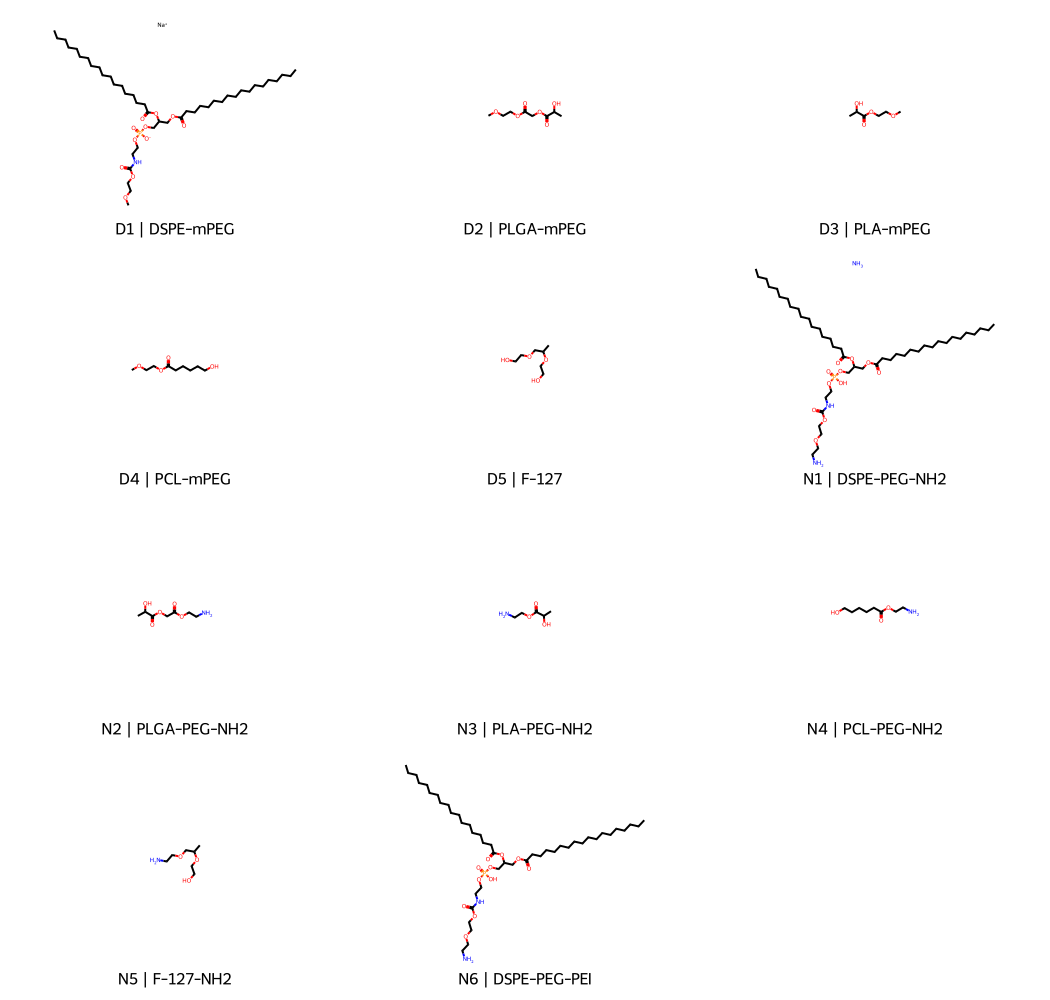

In [106]:
# Visualize valid carrier structures

molecules = valid_carriers["Molecule"].tolist()

legends = (
    valid_carriers["Carrier_ID"]
    + " | "
    + valid_carriers["Carrier_Name"]
).tolist()

Draw.MolsToGridImage(
    molecules,
    legends=legends,
    molsPerRow=3,
    subImgSize=(350, 250)
)